In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("transactions_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          object 
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             float64
 10  mcc             int64  
 11  errors          object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.2+ GB


In [4]:
df.isnull().sum()

id                       0
date                     0
client_id                0
card_id                  0
amount                   0
use_chip                 0
merchant_id              0
merchant_city            0
merchant_state     1563700
zip                1652706
mcc                      0
errors            13094522
dtype: int64

In [5]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['amount'] = df['amount'].str.replace('$','', regex=False).astype(float)

In [6]:
df

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,23761868,2019-10-31 23:56:00,1718,2379,1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,NaN
13305911,23761869,2019-10-31 23:56:00,1766,2066,12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,NaN
13305912,23761870,2019-10-31 23:57:00,199,1031,40.44,Swipe Transaction,2925,Allen,TX,75002.0,4900,NaN
13305913,23761873,2019-10-31 23:58:00,1986,5443,4.00,Chip Transaction,46284,Daly City,CA,94014.0,5411,NaN


In [7]:
#1 Does transaction amount indicate risk?
#2 Does time of transaction matter
#3️ Does payment method matter?
#4️ Does location influence transaction behavior?
#5️ Are errors random or systematic?
#6️ Do certain merchants look suspicious?
#7️ Does transaction velocity matter?
#8️ What simple rules could flag risk?

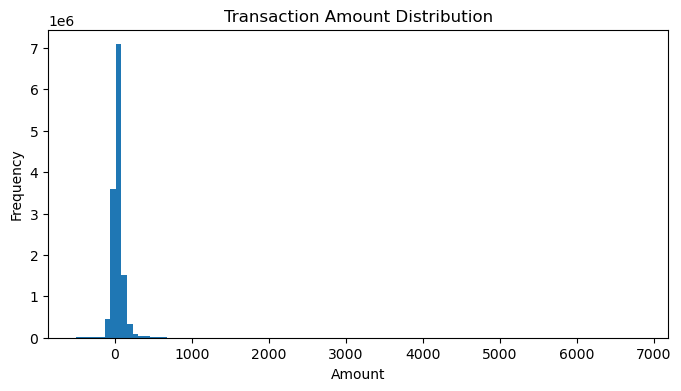

,count,mean,std,min,25%,50%,75%,max
has_error,,,,,,,,
False,13094522.0,42.701461,81.865869,-500.0,8.82,28.60,63.00,6820.20
True,211393.0,59.984472,65.156464,-497.0,23.66,57.04,86.47,3613.22


In [8]:
#1 Does transaction amount indicate risk?

#Create a risk flag
df['has_error'] = df['errors'].notna()

#Understand amount distribution (baseline)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(df['amount'], bins=100)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

#Compare amounts: error vs no-error
df.groupby('has_error')['amount'].describe()



<Figure size 600x400 with 0 Axes>

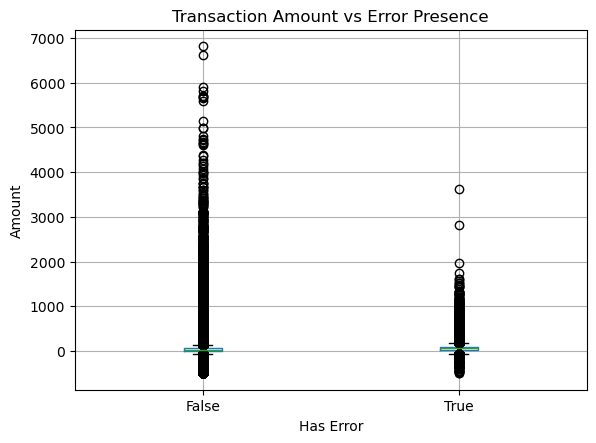

In [9]:
# Visual proof
plt.figure(figsize=(6,4))
df.boxplot(column='amount', by='has_error')
plt.title("Transaction Amount vs Error Presence")
plt.suptitle("")
plt.xlabel("Has Error")
plt.ylabel("Amount")
plt.show()


In [10]:
#High-value transaction test (business logic)
threshold = df['amount'].quantile(0.95)

high_value = df[df['amount'] >= threshold]

high_value['has_error'].value_counts(normalize=True)


has_error
False    0.982633
True     0.017367
Name: proportion, dtype: float64

In [11]:
df['has_error'].value_counts(normalize=True)
df['merchant_state'].nunique()


199

### Insight
Transaction amount analysis reveals a clear structural shift between normal and abnormal transactions. The median transaction amount for error cases (~57) is nearly double that of non-error transactions (~29), and both the 25th and 75th percentiles are consistently higher. This indicates that abnormal transactions are not driven solely by extreme outliers, but rather occur at systematically higher amounts across the distribution. Interestingly, the absolute maximum transaction values appear in the non-error group, suggesting that extremely large transactions may often be legitimate business or high-limit transactions rather than fraud indicators. Overall, transaction amount acts as a strong but non-exclusive risk signal.

In [12]:
#2 Does time of transaction matter
df['hour'] = df['date'].dt.hour

def categorize_time(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df['time_bucket'] = df['hour'].apply(categorize_time)
#error flag!
df['has_error'] = df['errors'].notna()
#group by time bucket
df.groupby('time_bucket')['has_error'].agg(['count', 'mean'])

,count,mean
time_bucket,,
Afternoon,4946907,0.016702
Evening,1778152,0.016932
Morning,5232719,0.014596
Night,1348137,0.016532


### Insight

While transaction volume is highest during morning hours, the error rate is slightly elevated during evening and afternoon periods. However, the variation across time buckets is modest, suggesting that time of day alone is not a strong standalone risk indicator.

In [13]:
#Q3 Does payment method matter?
df.groupby('use_chip')['has_error'].agg(['count', 'mean'])

,count,mean
use_chip,,
Chip Transaction,4780818,0.015122
Online Transaction,1557912,0.022826
Swipe Transaction,6967185,0.014861


### Insight

Online transactions exhibit a significantly higher error rate compared to chip and swipe transactions. Although online transactions account for a smaller share of total activity, they demonstrate a disproportionately higher abnormality rate, suggesting that online payment channels represent a higher-risk environment.

In [14]:
#Q4 does place influences transactional behaviour?

# first we group by state to decrease the noise
df.groupby('merchant_state')['has_error'].agg(['count', 'mean']).sort_values('mean', ascending=False)

#Level 2: Filter High-Volume Cities Only
city_stats = df.groupby('merchant_city')['has_error'].agg(['count', 'mean'])

# Keep cities with at least 50,000 transactions
city_stats = city_stats[city_stats['count'] > 50000]

city_stats.sort_values('mean', ascending=False) 

,count,mean
merchant_city,,
Orlando,57653,0.026833
Atlanta,54256,0.024808
ONLINE,1563700,0.022742
Dallas,71864,0.020177
Los Angeles,82004,0.017267
San Antonio,59265,0.016468
Tucson,53815,0.015832
Philadelphia,61419,0.015712
Bronx,52370,0.015333


### Insight
Certain cities such as Orlando and Atlanta exhibit noticeably higher transaction error rates compared to the overall baseline. Additionally, transactions categorized under "ONLINE" show elevated abnormality rates, reinforcing earlier findings that digital channels present higher operational risk. However, many high-volume metropolitan areas maintain error rates near or below baseline, suggesting that transaction volume alone does not determine risk concentration.

### Insight
Error occurrences are not uniformly distributed across transaction attributes. While time-of-day shows only mild variation, payment method and certain geographic locations exhibit noticeably elevated error rates. This suggests that transaction errors are influenced by systematic factors rather than occurring purely at random.

In [15]:
#Q6 Do certain merchants look suspicious?
merchant_stats = df.groupby('merchant_id')['has_error'].agg(['count', 'mean'])

#Filter low-volume merchants
merchant_stats = merchant_stats[merchant_stats['count'] > 5000]

#Sort by error rate
merchant_stats.sort_values('mean', ascending=False).head(10)

,count,mean
merchant_id,,
64057,9676,0.043303
37369,8967,0.042601
59350,10217,0.039444
80770,10051,0.036016
96529,6347,0.033244
31707,6457,0.032987
61641,6288,0.032761
87530,9163,0.032522
4802,6431,0.032499


In [16]:
df.groupby('mcc')['has_error'].agg(['count', 'mean']).sort_values('mean', ascending=False)

,count,mean
mcc,,
7922,39544,0.032571
4899,51526,0.031091
4111,84105,0.031021
4829,589140,0.030903
7801,17549,0.027979
...,...,...
3144,334,0.002994
3066,2714,0.002948
3006,351,0.002849


In [17]:
df[df['merchant_id'].isin([64057,37369,59350,80770,96529])]['mcc'].value_counts()

mcc
7922    20268
4111    18643
4899     6347
Name: count, dtype: int64

### Insight 
Merchant-level analysis reveals that several high-volume merchants exhibit error rates significantly above the baseline. Further inspection shows that these merchants cluster within specific MCC categories, suggesting that transaction risk is more strongly associated with merchant type or industry than with individual merchants alone.

In [18]:
# 7 Does transaction velocity matter?
velocity = (
    df.groupby(['card_id', 'hour'])
      .size()
      .reset_index(name='tx_count')
)

#Merge back to original dataframe
df = df.merge(velocity, on=['card_id', 'hour'], how='left')
df['high_velocity'] = df['tx_count'] >= 4

#comparing error rates
df.groupby('high_velocity')['has_error'].mean()


high_velocity
False    0.013192
True     0.015891
Name: has_error, dtype: float64

### Insight 
Transactions occurring in high-velocity bursts exhibit a moderately elevated error rate compared to normal transaction flow. While the increase is not extreme, the consistent upward shift suggests that transaction velocity contributes incremental risk and may serve as a useful complementary signal when combined with other factors.

### What simple rules could flag risk?
A rule-based fraud monitoring system should adopt a risk-scoring approach rather than binary flagging. Individual signals such as online channel, high transaction amount, elevated merchant risk, and high transaction velocity contribute incremental risk. Transactions exceeding a cumulative risk threshold should be subject to additional verification rather than automatic blocking, minimizing false positives while maintaining security.